In [6]:
import numpy as np
import matplotlib.pyplot as plt
import nets as nets

In [7]:
#Mismo sistema que para temporal difference pero sin politica definida

X = np.linspace(-5, 5, 101)   # estados discretos
A = np.array([-1.0, 0.0, 1.0]) #Acciones

Q = np.zeros((len(X), len(A)))

def closest_state(x):
    return np.argmin(np.abs(X - x))

def step(x, u):
    x_next = x + u
    r = -x**2
    return x_next, r


In [8]:
alpha = 0.2
gamma = 0.99
eps = 0.2

for episode in range(20000):

    x = np.random.uniform(-5, 5)
    s = closest_state(x)

    if np.random.rand() < eps:
        a_idx = np.random.randint(len(A))
    else:
        a_idx = np.argmax(Q[s])

    u = A[a_idx]

    x_next, r = step(x, u)
    s_next = closest_state(x_next)

    td_target = r + gamma * np.max(Q[s_next])
    td_error = td_target - Q[s, a_idx]

    Q[s, a_idx] += alpha * td_error


policy = A[np.argmax(Q, axis=1)]


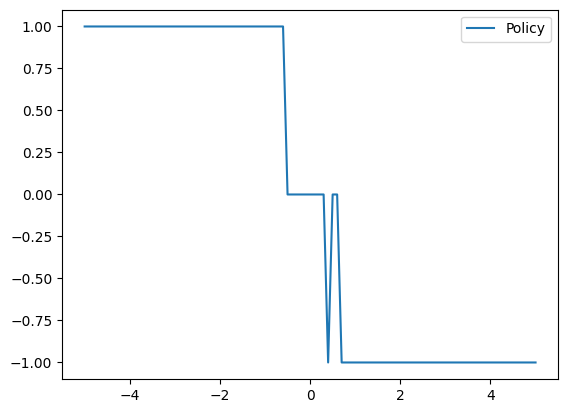

In [9]:
plt.plot(X, policy)
plt.legend(["Policy"])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

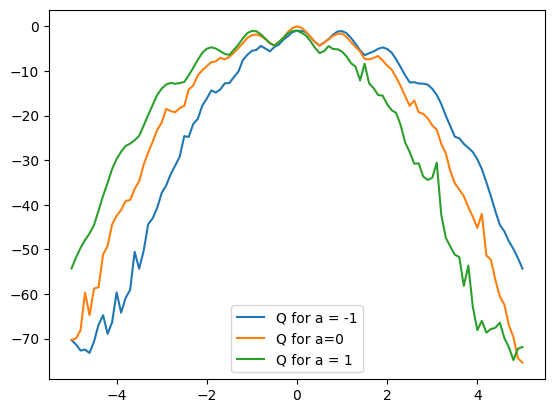

In [10]:
plt.plot(X, Q[:,0])
plt.plot(X, Q[:,1])
plt.plot(X, Q[:,2])
plt.legend(["Q for a = -1", "Q for a=0", "Q for a = 1"])
plt.show